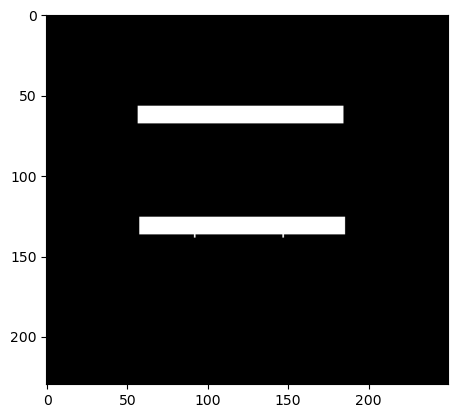

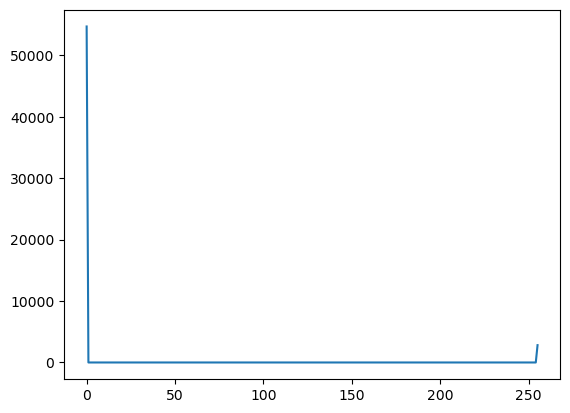

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

rect = cv2.imread('rect.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(rect, cmap='gray', vmin=0, vmax=255)
plt.show()

rect_hist = cv2.calcHist([rect], [0], None, [256], [0, 256])
plt.plot(rect_hist)
plt.show()



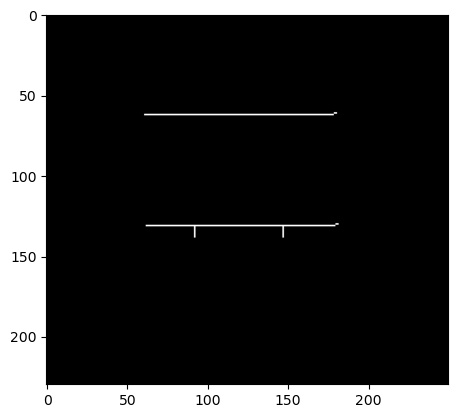

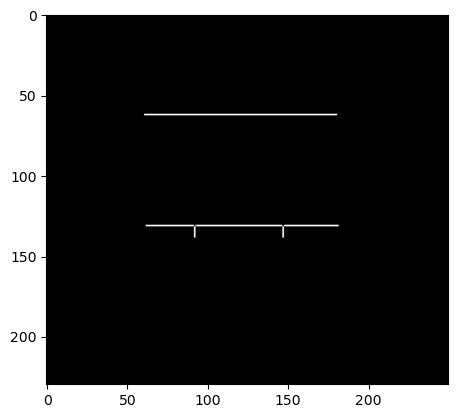

In [2]:
from skimage.morphology import skeletonize, thin

sk_image = skeletonize(rect) # zhang defeault para imagenes 2d

plt.imshow(sk_image, cmap='gray', vmin=0, vmax=1)
plt.show()


sk_image_lee = skeletonize(rect,method='lee')

plt.imshow(sk_image_lee, cmap='gray', vmin=0, vmax=1)
plt.show()






# cómo funcionan ambos algoritmos en términos generales
Zhang tiene dos fases, en la primera elimina los elementos en la parte superior derecha del objeto mediante mascaras donde si se hallan pixeles en donde hay 1 y vacio donde hay 0 se elimina el pixel x.En la segunda fase se eliminan los elementos de la parte inferior derecha
repitiendo la lógica de la anterior y repitiendo ambas fases en varias iteraciones hasta tener el esqueleto.

Lee, tiene una sola fase en la cual detecta si el pixel es parte del borde y solo se elimina el pixel si no rompe la conectividad del objeto lo cual es revisado mediante el número de euler. Esto se repite de forma iterativa hasta llegar al esqueleto. Este algoritmo se puede utilizar en imágenes 3d.

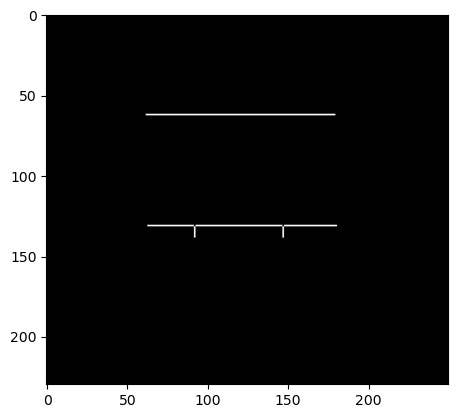

In [3]:
th_image = thin(rect)
plt.imshow(th_image, cmap='gray', vmin=0, vmax=1)
plt.show()




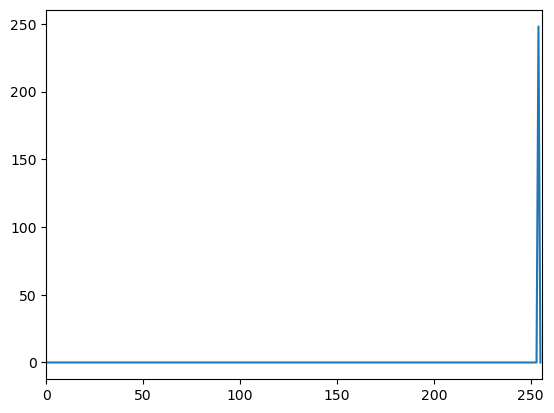

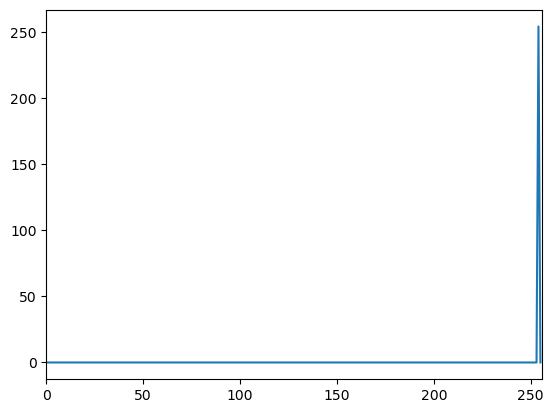

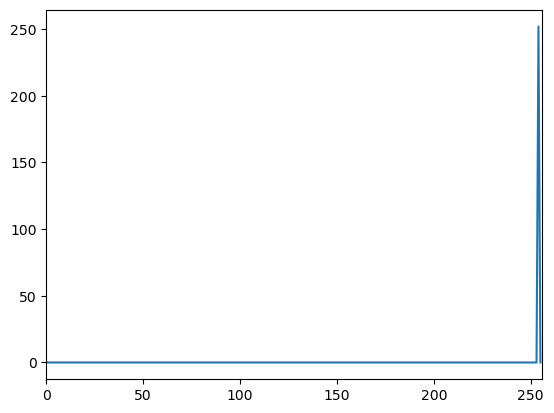

In [4]:
from skimage import exposure

rescaled_img = exposure.rescale_intensity(th_image.astype(np.uint8), in_range=(0, 1), out_range=(0, 255))
rescaled_img = rescaled_img.astype(np.uint8)
rescaled_img_hist = cv2.calcHist([rescaled_img], [0], None, [256], [10, 256])
plt.plot(rescaled_img_hist)
plt.xlim([0, 256])
plt.show()

rescaled_sk_image = exposure.rescale_intensity(sk_image.astype(np.uint8), in_range=(0, 1), out_range=(0, 255))
rescaled_sk_image = rescaled_sk_image.astype(np.uint8)
rescaled_sk_image_hist = cv2.calcHist([rescaled_sk_image], [0], None, [256], [10, 256])
plt.plot(rescaled_sk_image_hist)
plt.xlim([0, 256])
plt.show()

rescaled_sk_image_lee = exposure.rescale_intensity(sk_image_lee.astype(np.uint8), in_range=(0, 1), out_range=(0, 255))
rescaled_sk_image_lee = rescaled_sk_image_lee.astype(np.uint8)
rescaled_sk_image_lee_hist = cv2.calcHist([rescaled_sk_image_lee], [0], None, [256], [10, 256])
plt.plot(rescaled_sk_image_lee_hist)
plt.xlim([0, 256])    
plt.show()




# Compare el resultado con los de la esqueletización.
Se puede evidenciar que en cuanto a intensidad del color ambos son muy parecidos. con respecto a la forma, en este caso se puede ver que thin se desepeña de forma muy similar a esqueletamiento por el algoritmo de lee. Esto se debe a que es una figura simple, por lo que se puede conseguir el esqueleto de la imagen solo adelgazandola ya que por la naturaleza de su figura se puede llegar a un pixel de grosor sin afectar la conectividad mediante adelgazamiento, es decir, se puede llegar a su esqueleto.

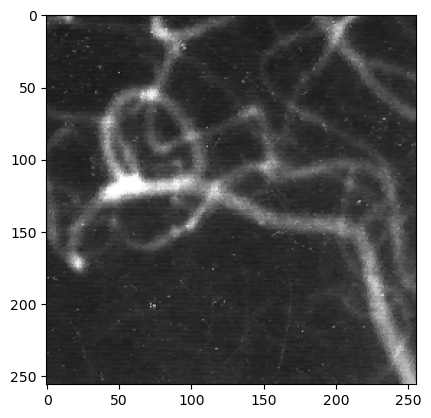

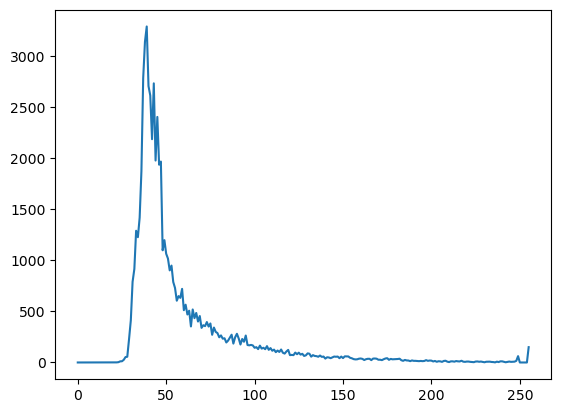

In [5]:

angio = cv2.imread('angio.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(angio, cmap='gray', vmin=0, vmax=255)
plt.show()

angio_hist = cv2.calcHist([angio], [0], None, [256], [0, 256])
plt.plot(angio_hist)
plt.show()

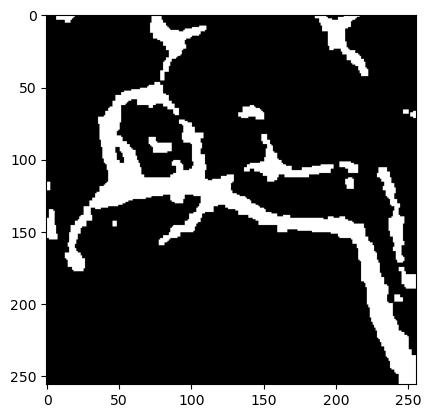

In [6]:

from skimage.morphology import dilation, erosion, opening, closing


footprint = np.ones((3,3), dtype=np.uint8)
thres_value, angio_mod = cv2.threshold(angio, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
angio_mod = closing(angio_mod, footprint=footprint)
angio_mod = opening(angio_mod, footprint=footprint)


plt.imshow(angio_mod, cmap='gray', vmin=0, vmax=255)
plt.show()


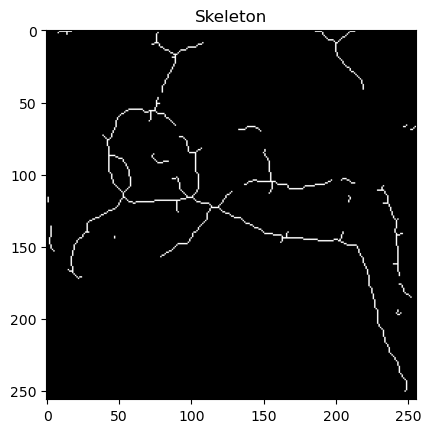

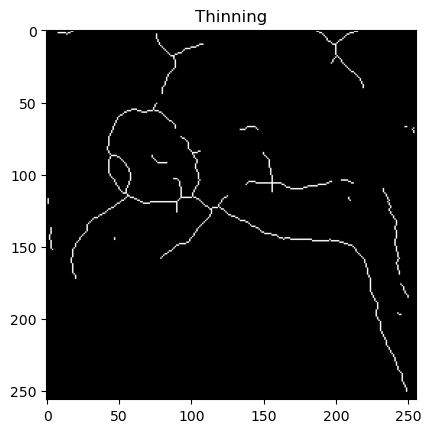

In [7]:
from skimage.morphology import skeletonize, thin

sk_image = skeletonize(angio_mod)
th_image = thin(angio_mod)

plt.imshow(sk_image, cmap='gray', vmin=0, vmax=1)
plt.title('Skeleton')
plt.show()

plt.imshow(th_image, cmap='gray', vmin=0, vmax=1)
plt.title('Thinning')
plt.show()


# Compare los resultados de estos dos tratamientos.
Se puede evidenciar que ambas figuras adelgazan al rededor de un pixel de grosor las diferentes areas que se encuentran en la imagén. Sin embargo, se pude identificar una diferencia en cuanto a que el esqueleto es más sensible a los cambios de grosor de la figura, llevando a la generación de pequeñas ramas que se pueden identificar a lo largo del objeto, algo que no sucede en el adelgazamiento que es menos sensible a esos cambios en la forma.

Text(0.5, 1.0, 'Superpuesta')

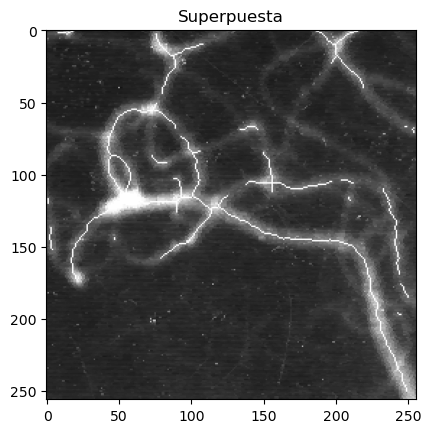

In [8]:
superpuesta = np.maximum(angio, th_image*255)
plt.imshow(superpuesta, cmap='gray', vmin=0, vmax=255)
plt.title('Superpuesta')


#  Describa de forma cualitativa el resultado obtenido. 
Se puede identificar que la linea adelgazada sigue la figura de los cordones con niveles de intensidad más altos. No las sigue por completo, pero logra representar a nivel general por donde pasa. Sin embargo, no representa la totalidad de la figura ya que hay zonas donde marca pequeñas líneas que, a pesar de ser parte de un cordon, no logran representar bien la figura al estar desconectadas. Además, hay muchas líneas que se quedaron sin su representación en la versión adelgazada de la figura.